In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import re
import joblib

In [2]:
df_train = pd.read_csv(r"..\data\Language Identification\train.csv")
df_valid = pd.read_csv(r"..\data\Language Identification\train.csv")
df_test = pd.read_csv(r"..\data\Language Identification\train.csv")

In [3]:
df_train.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [39]:
df_train.duplicated().sum()

1020

In [41]:
df_train.drop_duplicates(inplace=True)

In [42]:
df_train.duplicated().sum()

0

Zero duplicates now!

In [7]:
df_train['labels'].value_counts()

labels
pt    3500
bg    3500
en    3500
vi    3500
fr    3500
nl    3500
el    3500
de    3500
hi    3500
it    3500
ar    3500
es    3500
tr    3500
sw    3500
ur    3500
pl    3500
ru    3500
th    3500
zh    3500
ja    3500
Name: count, dtype: int64

<Axes: xlabel='labels', ylabel='count'>

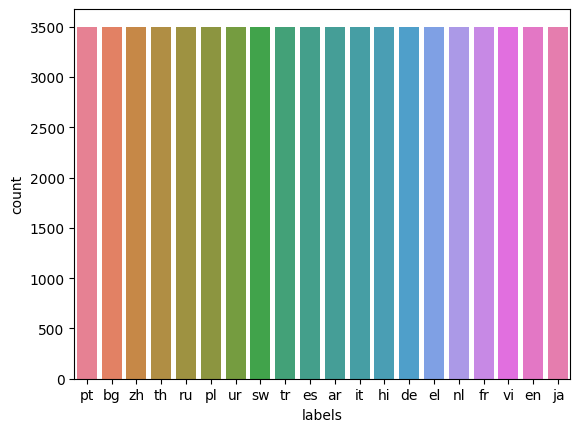

In [33]:
sns.countplot(x=df_train['labels'],hue=df_train['labels'])

The dataset is perfectly balanced 

## Data Preprocessing

we will do simple preprocessing such as removing links,numbers and lowercasing latin characters 

we only need this as these are language agnostic

In [12]:
from sklearn.base import BaseEstimator, TransformerMixin

class TextTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass 
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return [self._clean_text(text) for text in X]

    def _clean_text(self, text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'http\S+|www\.\S+', '', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

In [13]:
X_train = df_train['text']
y_train = df_train['labels']

In [18]:
X_valid = df_valid['text']
y_valid = df_valid['labels']

In [53]:
X_test = df_test['text']
y_test = df_test['labels']


In [16]:
from sklearn.metrics import classification_report

## Models Training and validation

In [51]:
model0 =  Pipeline([
    ('cleaner', TextTransformer()),
    ('vectorizer', CountVectorizer(analyzer='char')),
    ('classifier', LinearSVC())
])
model0.fit(X_train,y_train)

Pipeline(steps=[('cleaner', TextTransformer()),
                ('vectorizer', CountVectorizer(analyzer='char')),
                ('classifier', LinearSVC())])

In [52]:
predictions = model0.predict(X_valid)
print(classification_report(y_valid, predictions))
accuracy = model0.score(X_valid,y_valid)
print(f"Validation Accuracy: {accuracy:.4f}")

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00      3500
          bg       0.96      0.98      0.97      3500
          de       0.97      0.96      0.96      3500
          el       1.00      1.00      1.00      3500
          en       0.93      0.93      0.93      3500
          es       0.94      0.89      0.91      3500
          fr       0.96      0.94      0.95      3500
          hi       1.00      1.00      1.00      3500
          it       0.86      0.93      0.89      3500
          ja       1.00      1.00      1.00      3500
          nl       0.86      0.92      0.89      3500
          pl       0.99      0.96      0.98      3500
          pt       0.91      0.90      0.91      3500
          ru       0.98      0.95      0.97      3500
          sw       0.94      0.95      0.95      3500
          th       1.00      1.00      1.00      3500
          tr       0.99      0.95      0.97      3500
          ur       0.99    

In [ ]:
model1 = Pipeline([
    ('cleaner', TextTransformer()),
    ('vectorizer', TfidfVectorizer(analyzer='char', ngram_range=(1, 3), max_features=5000)),
    ('classifier', LinearSVC())
])
model1.fit(X_train,y_train)

Pipeline(steps=[('cleaner', TextTransformer()),
                ('vectorizer',
                 TfidfVectorizer(analyzer='char', max_features=5000,
                                 ngram_range=(1, 3))),
                ('classifier', LinearSVC())])

In [43]:
predictions = model1.predict(X_valid)
print(classification_report(y_valid, predictions))
accuracy = model1.score(X_valid,y_valid)
print(f"Validation Accuracy: {accuracy:.4f}")


              precision    recall  f1-score   support

          ar       1.00      1.00      1.00      3500
          bg       0.99      1.00      1.00      3500
          de       1.00      1.00      1.00      3500
          el       1.00      1.00      1.00      3500
          en       0.99      1.00      1.00      3500
          es       1.00      1.00      1.00      3500
          fr       1.00      1.00      1.00      3500
          hi       1.00      1.00      1.00      3500
          it       1.00      1.00      1.00      3500
          ja       1.00      1.00      1.00      3500
          nl       1.00      1.00      1.00      3500
          pl       1.00      1.00      1.00      3500
          pt       1.00      1.00      1.00      3500
          ru       1.00      0.99      1.00      3500
          sw       1.00      1.00      1.00      3500
          th       1.00      1.00      1.00      3500
          tr       1.00      1.00      1.00      3500
          ur       1.00    

In [ ]:
model2 = Pipeline([
    ('cleaner', TextTransformer()),
    ('vectorizer', TfidfVectorizer(analyzer='char', ngram_range=(2, 4), max_features=15000)),
    ('classifier', LinearSVC())
])
model2.fit(X_train,y_train)

Pipeline(steps=[('cleaner', TextTransformer()),
                ('vectorizer',
                 TfidfVectorizer(analyzer='char', max_features=15000,
                                 ngram_range=(2, 4))),
                ('classifier', LinearSVC())])

In [46]:
predictions = model2.predict(X_valid)
print(classification_report(y_valid, predictions))
accuracy = model2.score(X_valid,y_valid)
print(f"Validation Accuracy: {accuracy:.4f}")


              precision    recall  f1-score   support

          ar       1.00      1.00      1.00      3500
          bg       1.00      1.00      1.00      3500
          de       1.00      1.00      1.00      3500
          el       1.00      1.00      1.00      3500
          en       1.00      1.00      1.00      3500
          es       1.00      1.00      1.00      3500
          fr       1.00      1.00      1.00      3500
          hi       1.00      1.00      1.00      3500
          it       1.00      1.00      1.00      3500
          ja       1.00      1.00      1.00      3500
          nl       1.00      1.00      1.00      3500
          pl       1.00      1.00      1.00      3500
          pt       1.00      1.00      1.00      3500
          ru       1.00      1.00      1.00      3500
          sw       1.00      1.00      1.00      3500
          th       1.00      1.00      1.00      3500
          tr       1.00      1.00      1.00      3500
          ur       1.00    

In [56]:
model3 = Pipeline([
    ('cleaner', TextTransformer()),
    ('vectorizer', TfidfVectorizer(analyzer='char', ngram_range=(2, 4), max_features=15000)),
    ('classifier', LogisticRegression())
])
model3.fit(X_train,y_train)

Pipeline(steps=[('cleaner', TextTransformer()),
                ('vectorizer',
                 TfidfVectorizer(analyzer='char', max_features=15000,
                                 ngram_range=(2, 4))),
                ('classifier', LogisticRegression())])

In [57]:
predictions = model3.predict(X_valid)
print(classification_report(y_valid, predictions))
accuracy = model3.score(X_valid,y_valid)
print(f"Validation Accuracy: {accuracy:.4f}")

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00      3500
          bg       0.99      0.99      0.99      3500
          de       1.00      1.00      1.00      3500
          el       1.00      1.00      1.00      3500
          en       0.99      1.00      0.99      3500
          es       1.00      1.00      1.00      3500
          fr       1.00      1.00      1.00      3500
          hi       1.00      1.00      1.00      3500
          it       1.00      1.00      1.00      3500
          ja       1.00      1.00      1.00      3500
          nl       1.00      1.00      1.00      3500
          pl       1.00      0.99      1.00      3500
          pt       1.00      1.00      1.00      3500
          ru       1.00      0.99      0.99      3500
          sw       1.00      0.99      0.99      3500
          th       1.00      1.00      1.00      3500
          tr       1.00      1.00      1.00      3500
          ur       1.00    

## Testing

testing our best model

In [55]:
model2.score(X_test,y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9632


In [58]:
final_model = model2

## testing the model manually 

In [ ]:
samples = ["Hello my name is Travis",
           "صباح الفل علي الجميع", # arabic
           "messi es el mejor jugador del mundo", #spanish
           "я очень голоден"] #russian
final_model.predict(samples)

array(['en', 'ar', 'es', 'ru'], dtype=object)

## Exporting Model

In [62]:
joblib.dump(final_model, '../models/language_detector_v1.0.joblib')
print("Model exported successfully!")    

Model exported successfully!
